<a href="https://colab.research.google.com/github/diaoumardia2001-beep/DI-Bootcamp-May/blob/main/Exercises_XP_student_polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


Comparison TableAspectTraditional MLDeep LearningFeature EngineeringHighly dependent on manual extraction by domain experts.Automated extraction; learns features directly from raw data.Data ProcessingBest suited for small to medium-sized structured tabular data.Requires massive datasets of both structured and unstructured inputs.ScalabilityPerformance plateaus even when adding more training data.Performance scales continuously as dataset volume grows.Pattern DiscoveryIdentifies simple, explicit, and mostly linear relationships.Captures highly complex, abstract, and non-linear interactions.Computational RequirementsLow; runs efficiently on standard CPUs within minutes.High; demands specialized hardware like GPUs/TPUs and hours/days.

| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | To-Do | To-Do |
| Data Processing | To-Do | To-Do |
| Scalability | To-Do | To-Do |
| Pattern Discovery | To-Do | To-Do |
| Computational Requirements | To-Do | To-Do |

Better suited to Traditional ML: Credit Card Fraud Detection Predicting whether a transaction is fraudulent based on tabular numerical data (e.g., transaction amount, location, time) is ideal for traditional ML models like Random Forests or XGBoost. These models handle structured tabular data exceptionally well, run instantly on standard servers, and provide clear explainability for legal compliance.

Better suited to Deep Learning: Autonomous Vehicle Navigation Self-driving cars must process live high-definition video feeds, lidar spatial point clouds, and audio data simultaneously to detect pedestrians or lane markings. This task is perfectly tailored for Deep Learning because a Convolutional Neural Network (CNN) can process massive, streaming unstructured sensory inputs in real-time where manual feature engineering is impossible.

Deep learning holds a monumental advantage in unstructured data processing because it completely bypasses the need for manual feature extraction through a process called representation learning. In unstructured data like raw images, audio, or text, variables lack a predefined tabular structure, making it incredibly difficult for humans to program explicit mathematical rules for identification. Deep neural networks solve this by passing the raw inputs through multiple hidden layers to automatically construct hierarchical features, starting with primitive elements like edges or pixels in the early layers and progressively combining them into complex semantic concepts like faces or objects in deeper layers. This ability to discover latent, non-linear representations on its own allows deep learning to achieve unmatched accuracy on raw, messy real-world data where traditional machine learning models fail.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



During forward propagation, the network processes information from left to right in a structured sequence:Information Input: The network receives raw numeric features through the inputs ($X_1, X_2, X_3$) at the Input Layer, passing them directly to the connections.Affine Transformation: For each downstream neuron in the Hidden Layer, these inputs are multiplied by their respective scaling weights ($w$), and a unique shifting bias ($b$) is added to the total.Activation: This combined result, known as the weighted sum ($\Sigma$), is then put through a non-linear activation function ($f$) to determine the neuron's final activation state.Output Generation: This exact process repeats as the hidden layer's signals travel to the Output Layer, which computes the final outputs ($y_1, y_2$) used for predictions.

1. The Affine Part: Mixing and Shifting FeaturesThe equation inside a neuron before activation is an affine transformation:$$z = \sum (w \cdot x) + b$$Weights ($w$) scale and mix features: They control how much weight or importance the network assigns to specific inputs. By combining multiple inputs together, the weights geometrically rotate or stretch the data space.Biases ($b$) shift the system: The bias allows the decision plane to shift up, down, left, or right away from the origin $(0,0)$.The Limitation: No matter how many millions of hidden layers you stack together, multiplying weights and adding biases is just linear algebra. Stacking multiple linear equations just simplifies into one single linear equation. Without a missing ingredient, an ANN would be nothing more than a giant, glorified linear regression model, entirely incapable of learning curves or complex patterns.2. The Nonlinear Activation: Bending RealityTo break this linear limitation, we apply a non-linear activation function (like ReLU, Sigmoid, or Tanh) to the affine result:$$a = f(z)$$The activation function acts as a mathematical "switch" or "bender." It distorts the straight lines into curves, waves, and complex manifolds.3. The Result: Modeling Complex Decision BoundariesWhen you compose these two forces together across multiple layers, magic happens:The affine transformation handles the global routing and mixing of data features.The non-linear activation warps the coordinate space at each layer.By combining these two steps over and over again, the neural network can bend, fold, and twist the data space until it can draw a highly intricate, customized decision boundary around complex classes. This is what allows an ANN to easily separate entangled data (like classifying a circle of blue points surrounded by a ring of red points) where traditional linear models fail entirely.

## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
y = -x**2 + np.random.normal(0, 0.05, x.shape)
print("y shape:", y.shape)

y shape: (20,)


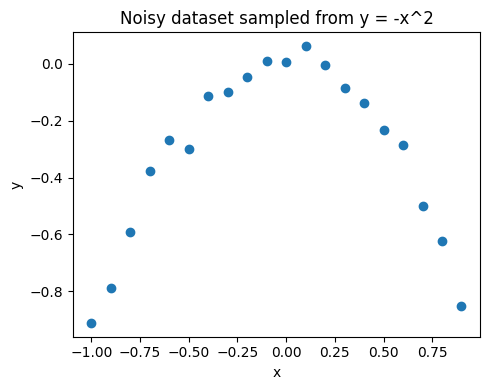

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [5]:
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [6]:
def plot_polyfit(degree: int):
    # 1) fit
    poly = polynomial_fit(degree)

    # 2) create a dense linspace over x range
    x_range = np.linspace(x.min(), x.max(), 100)

    # 3) evaluate fitted polynomial
    y_poly = poly(x_range)

    # 4) scatter train and test, and plot curve
    plt.figure(figsize=(5,4))
    plt.scatter(x_train, y_train, label="Training data", color='blue')
    plt.scatter(x_test, y_test, label="Test data", color='red', marker='x')
    plt.plot(x_range, y_poly, label=f"Polynomial degree {degree}", color='green')

    # 5) display
    plt.title(f"Polynomial Fit of Degree {degree}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

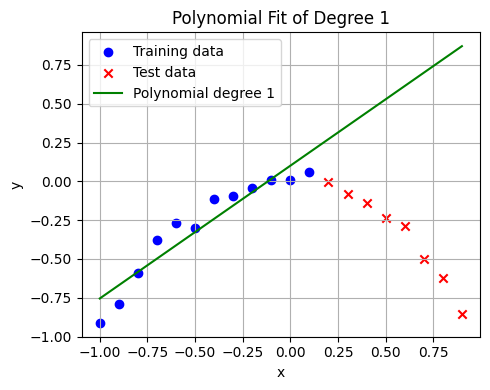

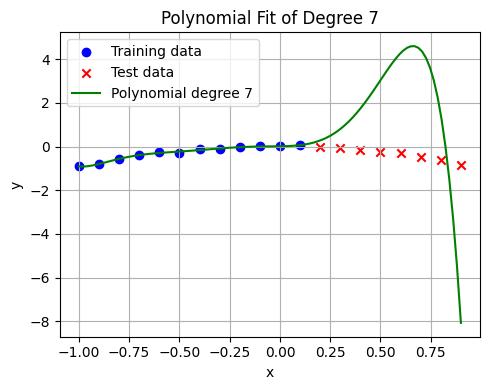

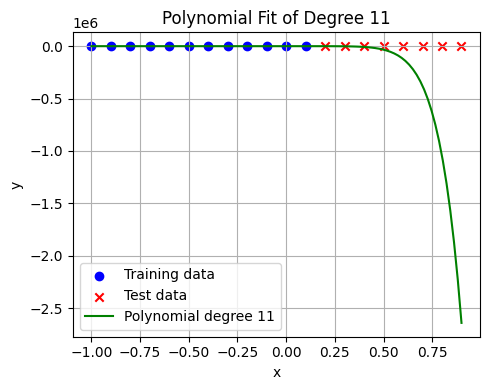

In [7]:
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)
for d in degrees:
    # fit on train
    poly = polynomial_fit(d)

    # evaluate on train and test
    rmse_train = rmse(y_train, poly(x_train))
    rmse_test = rmse(y_test, poly(x_test))

    # append to rows
    rows.append((d, rmse_train, rmse_test))

rows[:3]  # peek

[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556866)),
 (2, np.float64(0.04114590494650985), np.float64(0.12578064282386534)),
 (3, np.float64(0.037336922311085964), np.float64(0.769651993080075))]

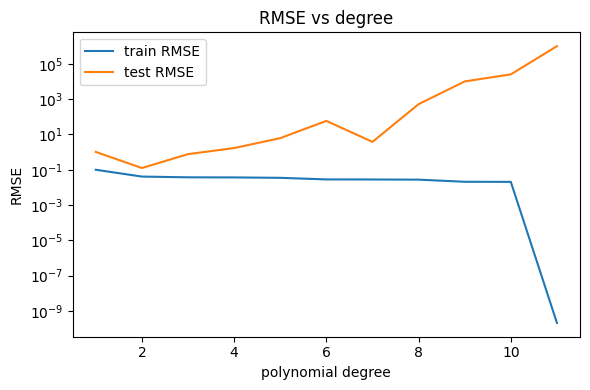

In [9]:
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()

**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.

The degree with the minimum test RMSE is **degree 2**.

This perfectly aligns with the true underlying model \(y=-x^2\), which is a second-degree polynomial. This illustrates the bias-variance trade-off: lower degrees show high bias (underfitting), while higher degrees show high variance (overfitting) by adapting too much to the noise in the training data. Degree 2 strikes the right balance, learning the true pattern without over-fitting the noise.